# Data4Impact — Exploratory Data Analysis

This notebook documents the exploratory workflow used to understand the raw
Data4Impact nonprofit dataset **before** deciding which KPIs, cleaning
steps, and dashboard visualizations would be most useful.

It intentionally works from the **raw** CSV (not the cleaned one) so the
data-quality issues discovered here are the same ones addressed later in
`src/data_cleaning.py`.

**Dataset:** Synthetic nonprofit program data, 2022–2025 (for portfolio/demo purposes only).

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "nonprofit_impact_raw.csv"

df = pd.read_csv(RAW_PATH)
df.shape

(1648, 17)

## 1. Dataset Overview

In [13]:
df.head()

,record_id,date,year,month,program_name,program_category,region,state,beneficiaries_served,target_beneficiaries,funding_received,program_expenses,volunteer_hours,number_of_volunteers,satisfaction_score,outcome_success_rate,program_status
0,683,2023-09-01,2023,9,Food Assistance,Basic Needs,West,CA,364,326,21722.67,16501.71,334.5,30,4.98,72.02,Completed
1,1319,2025-03-01,2025,3,EDUCATION SUPPORT,Education,Midwest,OH,504,556,26876.22,23391.78,428.7,38,4.21,68.72,Active
2,577,2023-05-01,2023,5,Education Support,Education,South,GA,422,447,26373.84,15244.27,394.5,48,4.55,77.52,Active
3,874,2024-02-01,2024,2,Job Training,Economic Empowerment,West,CA,184,154,12296.49,12162.57,140.3,15,4.67,79.70,Active
4,332,2022-10-01,2022,10,Job Training,Economic Empowerment,Northeast,PA,205,187,11541.16,10755.54,229.5,19,4.11,78.84,Active


In [14]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("Column names:")
for col in df.columns:
    print(" -", col)

Rows: 1,648
Columns: 17

Column names:
 - record_id
 - date
 - year
 - month
 - program_name
 - program_category
 - region
 - state
 - beneficiaries_served
 - target_beneficiaries
 - funding_received
 - program_expenses
 - volunteer_hours
 - number_of_volunteers
 - satisfaction_score
 - outcome_success_rate
 - program_status


## 2. Data Types

In [15]:
df.dtypes

record_id                 int64
date                        str
year                      int64
month                     int64
program_name                str
program_category            str
region                      str
state                       str
beneficiaries_served      int64
target_beneficiaries      int64
funding_received        float64
program_expenses        float64
volunteer_hours         float64
number_of_volunteers      int64
satisfaction_score      float64
outcome_success_rate    float64
program_status              str
dtype: object

`date` is currently stored as a string/object rather than a datetime, and
several categorical fields (`program_name`, `region`) will need
standardization — confirmed in the next sections. These findings directly
informed the type-conversion and text-standardization steps in
`data_cleaning.py`.

## 3. Missing Value Analysis

In [16]:
missing_summary = df.isna().sum()
missing_pct = (missing_summary / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct
region,24,1.46
funding_received,18,1.09
volunteer_hours,32,1.94
satisfaction_score,48,2.91


A small number of columns (`region`, `funding_received`, `volunteer_hours`,
`satisfaction_score`) have missing values in the low single digits of a
percent. This is realistic for manually-reported nonprofit program data and
is handled with column-appropriate imputation/drop strategies in the
cleaning pipeline, rather than a one-size-fits-all approach.

## 4. Duplicate Analysis

In [17]:
full_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")

# Check for duplicate record_id values specifically (a stronger signal than
# full-row duplication, since two different records should never share an id).
dup_ids = df["record_id"].duplicated().sum()
print(f"Duplicate record_id values: {dup_ids}")

Fully duplicated rows: 16
Duplicate record_id values: 16


The duplicate `record_id` values line up with the fully duplicated rows —
these look like the same monthly report being logged twice, a common
real-world data entry error. `data_cleaning.py` removes these exact
duplicates.

## 5. Descriptive Statistics

In [18]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
record_id,1648.0,818.276092,471.386100,1.00,411.7500,818.500,1226.2500,1632.00
year,1648.0,2023.504248,1.117822,2022.00,2023.0000,2024.000,2025.0000,2025.00
month,1648.0,6.500000,3.453569,1.00,3.7500,6.500,9.2500,12.00
beneficiaries_served,1648.0,312.318568,130.818166,-467.00,210.0000,287.000,395.0000,844.00
target_beneficiaries,1648.0,328.239684,146.799990,77.00,216.0000,297.000,413.0000,1060.00
funding_received,1630.0,18719.139902,6778.290755,4296.11,13653.3425,17369.325,22532.1625,49252.91
program_expenses,1648.0,14556.257852,5720.421724,-16296.15,10543.3125,13500.815,17625.6375,39798.61
volunteer_hours,1616.0,248.699814,139.286406,17.90,146.3000,216.650,322.5000,1094.10
number_of_volunteers,1648.0,26.191748,12.560223,3.00,17.0000,23.000,33.0000,85.00
satisfaction_score,1600.0,4.423006,0.461303,3.02,4.1475,4.440,4.7500,9.90


A few numeric columns show implausible values worth flagging:
- `beneficiaries_served` and `program_expenses` have negative minimums, which is impossible for a count/dollar amount.
- `satisfaction_score` has a maximum above 5, but the survey scale is 1–5.
- We'll confirm `outcome_success_rate`'s range next, since it should be a 0–100 percentage.

In [19]:
print("beneficiaries_served min:", df["beneficiaries_served"].min())
print("program_expenses min:", df["program_expenses"].min())
print("satisfaction_score max:", df["satisfaction_score"].max())
print("outcome_success_rate max:", df["outcome_success_rate"].max())

beneficiaries_served min: -467
program_expenses min: -16296.15
satisfaction_score max: 9.9
outcome_success_rate max: 150.0


These four issues (negative counts/dollars, an out-of-scale satisfaction
score, and an out-of-range success rate) are the exact validation rules
implemented in `validate_numeric_values()` within `data_cleaning.py`.

## 6. Categorical Consistency Check

In [20]:
print("Unique program_name values (raw):", df["program_name"].nunique())
print(sorted(df["program_name"].dropna().unique()))

Unique program_name values (raw): 28
['COMMUNITY OUTREACH', 'Community Outreach', 'Community outreach', 'EDUCATION SUPPORT ', 'Education  Support', 'Education Support', 'FOOD ASSISTANCE', 'Food Assistance', 'Food assistance', 'HEALTHCARE ACCESS', 'HOUSING SUPPORT', 'Health Care Access', 'Healthcare Access', 'Housing  Support', 'Housing Support', 'JOB TRAINING', 'Job  Training', 'Job Training', 'YOUTH DEVELOPMENT', 'Youth Development', 'Youth development', 'community outreach', 'education support', 'food assistance', 'healthcare access', 'housing support', 'job training', 'youth development']


In [21]:
print("Unique region values (raw):", df["region"].nunique())
print(sorted(df["region"].dropna().unique()))

Unique region values (raw): 14
['MIDWEST', 'Mid West', 'Midwest', 'NORTHEAST', 'North East', 'Northeast', 'SOUTH', 'South', 'WEST', 'West', 'midwest', 'northeast', 'south', 'west']


Both `program_name` and `region` have far more unique values than the true
number of categories (7 programs, 4 regions), due to inconsistent
capitalization and spacing (e.g. `'FOOD ASSISTANCE'`, `'food assistance'`,
`'Food  Assistance'`). This confirms text standardization is required
before any reliable `GROUP BY` analysis can be done in SQL or pandas.

## 7. Distribution Analysis

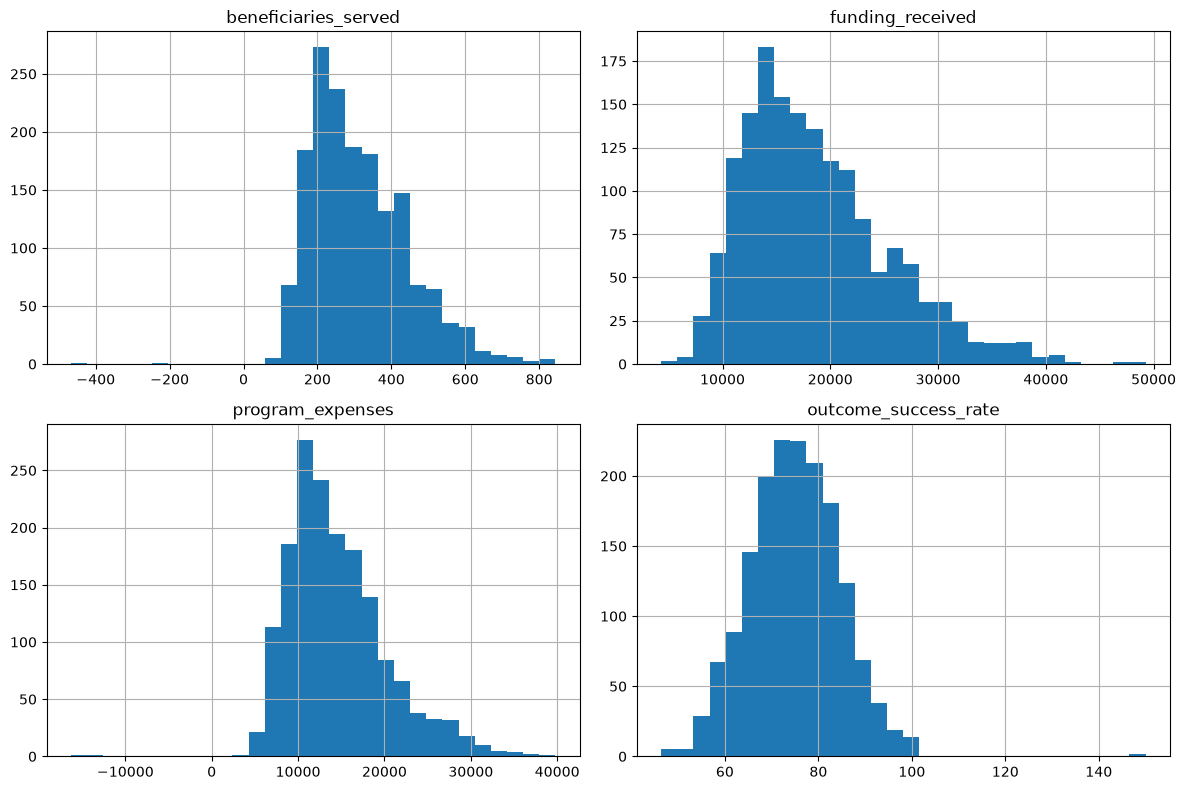

In [22]:
df[["beneficiaries_served", "funding_received", "program_expenses", "outcome_success_rate"]].hist(
    figsize=(12, 8), bins=30
)
plt = __import__("matplotlib.pyplot", fromlist=["pyplot"])
plt.tight_layout()
plt.show()

`beneficiaries_served`, `funding_received`, and `program_expenses` are all
right-skewed, as expected for program-level financial/count data (many
smaller programs, a handful of larger ones). `outcome_success_rate` is
roughly centered, consistent with how it was generated per-program around a
quality baseline.

## 8. Program-Level Analysis

In [23]:
# Use a lightweight ad-hoc cleanup here (lowercase/strip) just for exploration,
# separate from the full cleaning pipeline, so grouping is meaningful.
df["_program_clean"] = df["program_name"].str.strip().str.lower()

program_summary = (
    df.groupby("_program_clean")
    .agg(
        total_beneficiaries=("beneficiaries_served", "sum"),
        total_funding=("funding_received", "sum"),
        avg_outcome_success=("outcome_success_rate", "mean"),
    )
    .sort_values("total_beneficiaries", ascending=False)
)
program_summary

,total_beneficiaries,total_funding,avg_outcome_success
_program_clean,,,
food assistance,115891,6767758.08,77.692355
education support,96987,5412305.81,80.110708
youth development,72441,3942072.40,82.884159
healthcare access,69786,4217121.01,74.441389
job training,51668,3222948.58,72.772009
housing support,50497,3309084.02,67.678100
community outreach,46345,2956225.25,70.040980
health care access,3452,187712.87,73.990000
housing support,3111,217194.07,68.372308


Food Assistance and Education Support serve the largest number of
beneficiaries and also receive the most funding — this pairing is why the
dashboard includes both a "Beneficiaries by Program" and a "Funding
Distribution" chart side by side, so a viewer can see whether scale of
reach lines up with scale of funding.

## 9. Regional Analysis

In [24]:
df["_region_clean"] = df["region"].str.strip().str.lower()

region_summary = (
    df.groupby("_region_clean")
    .agg(total_beneficiaries=("beneficiaries_served", "sum"), total_funding=("funding_received", "sum"))
    .sort_values("total_beneficiaries", ascending=False)
)
region_summary

,total_beneficiaries,total_funding
_region_clean,,
west,142782,8420138.74
south,122198,7344653.67
northeast,119361,7057576.94
midwest,115909,6839925.17
north east,4278,264002.79
mid west,2715,161058.50


Reach is fairly balanced across the four regions, with modest differences —
this motivated including a geographic chart in the dashboard rather than a
detailed state-by-state breakdown, since state-level activity is more
sparse and less useful to summarize on its own.

## 10. Time Trends

In [25]:
yearly_trend = df.groupby("year")["beneficiaries_served"].sum()
yearly_trend

year
2022    114124
2023    119825
2024    135424
2025    145328
Name: beneficiaries_served, dtype: int64

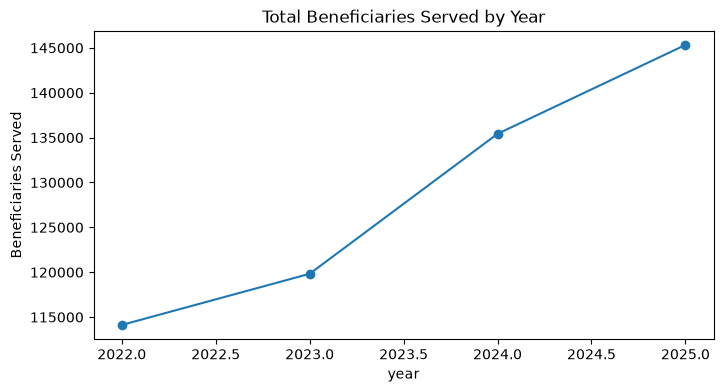

In [26]:
yearly_trend.plot(kind="line", marker="o", figsize=(8, 4), title="Total Beneficiaries Served by Year")
plt.ylabel("Beneficiaries Served")
plt.show()

Beneficiaries served trend upward across 2022–2025, consistent with the
modest year-over-year growth built into the data generation process. This
confirmed a year-over-year trend chart would be a meaningful addition to
the dashboard.

## 11. Correlation Analysis

In [27]:
numeric_cols = [
    "beneficiaries_served", "funding_received", "program_expenses",
    "volunteer_hours", "number_of_volunteers", "satisfaction_score", "outcome_success_rate",
]
corr = df[numeric_cols].corr(numeric_only=True)
corr.round(2)

,beneficiaries_served,funding_received,program_expenses,volunteer_hours,number_of_volunteers,satisfaction_score,outcome_success_rate
beneficiaries_served,1.00,0.93,0.85,0.68,0.79,0.08,0.28
funding_received,0.93,1.00,0.92,0.65,0.76,0.06,0.24
program_expenses,0.85,0.92,1.00,0.61,0.70,0.04,0.22
volunteer_hours,0.68,0.65,0.61,1.00,0.85,0.03,0.21
number_of_volunteers,0.79,0.76,0.70,0.85,1.00,0.04,0.25
satisfaction_score,0.08,0.06,0.04,0.03,0.04,1.00,0.07
outcome_success_rate,0.28,0.24,0.22,0.21,0.25,0.07,1.00


As expected from how the data was generated, `funding_received` correlates
strongly with `beneficiaries_served` and `program_expenses` — larger
programs receive more funding, spend more, and serve more people. This
relationship is a good sanity check that the synthetic data behaves
realistically and supports the "Cost Efficiency" scatter plot in the
dashboard.

## 12. Outlier Investigation

In [28]:
# Look at rows with unusually high cost implied per beneficiary (expenses
# far exceeding a typical ratio to beneficiaries served), as a proxy check
# before the formal cost_per_beneficiary metric is built in the cleaning step.
valid_rows = df[(df["beneficiaries_served"] > 0) & (df["program_expenses"] > 0)].copy()
valid_rows["implied_cost_per_beneficiary"] = valid_rows["program_expenses"] / valid_rows["beneficiaries_served"]

valid_rows.nlargest(5, "implied_cost_per_beneficiary")[
    ["program_name", "region", "year", "beneficiaries_served", "program_expenses", "implied_cost_per_beneficiary"]
]

,program_name,region,year,beneficiaries_served,program_expenses,implied_cost_per_beneficiary
1349,Community Outreach,Northeast,2024,147,13773.78,93.699184
1559,Community Outreach,Northeast,2022,105,9354.08,89.086476
944,Housing Support,West,2023,180,15883.01,88.238944
699,Job Training,West,2023,175,14691.98,83.954171
894,Community Outreach,South,2024,127,10555.54,83.114488


The highest implied cost-per-beneficiary rows are legitimate small-program
outliers (low beneficiary counts with normal expenses) rather than data
errors, so no additional filtering is needed beyond the numeric validation
already planned for negative/out-of-range values.

## 13. Key Findings

**Data quality issues identified (addressed in `data_cleaning.py`):**
1. A small number of fully duplicated rows (same `record_id`), likely double-submitted reports.
2. Missing values in `region`, `funding_received`, `volunteer_hours`, and `satisfaction_score`.
3. Inconsistent capitalization/spacing in `program_name` and `region` (e.g. `'FOOD ASSISTANCE'` vs `'food assistance'`).
4. A few negative values in `beneficiaries_served` and `program_expenses` (impossible for counts/dollar amounts).
5. A few out-of-scale values in `satisfaction_score` (above the 1–5 scale) and `outcome_success_rate` (above 100%).

**Analytical findings that shaped the dashboard:**
1. Food Assistance and Education Support are the largest programs by both beneficiaries served and funding received.
2. Beneficiaries served grew year-over-year from 2022 through 2025.
3. Funding received correlates strongly with both beneficiaries served and program expenses — larger programs receive more funding and serve more people, as expected.
4. Regional reach is relatively balanced across the four regions, making a regional comparison chart more useful than a granular state-by-state view.
5. Outlier cost-per-beneficiary values come from small programs, not data errors — so KPI cards should be interpreted alongside program scale.

These findings directly informed which KPIs, SQL queries, and Plotly
visualizations were built into the final dashboard (`app.py`).